In [8]:
library(tidyverse)
library(broom)
library(fixest)
final_analysis_data <- read_csv("../data/final_analysis_data.csv")

Rows: 54737 Columns: 58
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (43): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
lgl   (2): expand_ever, expand
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Question 1
Provide a table of mean hospital uncompensated care (in millions of dollars) by year, from 2010 through 2018. How has uncompensated care changed over time?

In [10]:
uncomp_summary_table <- final_analysis_data %>%
  filter(year >= 2010 & year <= 2018) %>%
  group_by(year) %>%
  summarize(
    mean_uncomp_millions = mean(uncomp_millions, na.rm = TRUE)
  ) %>%
  arrange(year)

uncomp_summary_table


year,mean_uncomp_millions
<dbl>,<dbl>
2010,9.790725
2011,5.330973
2012,5.634447
2013,6.065508
2014,4.803649
2015,3.860061
2016,4.126581
2017,4.928453
2018,4.958235


Uncompensated care has decreased a bit over time. It started at 9.79 million in 2010 and reached 4.96 million in 2018, between 2014 and 2018 uncompensated care decreased and increased a bit but mainly stayed in the range of 4-5 million

# Question 2
Plot mean uncompensated care over time separately for states that expanded Medicaid in 2014 versus states that never expanded. Drop all states that expanded after 2014. Does the graph suggest a potential treatment effect?

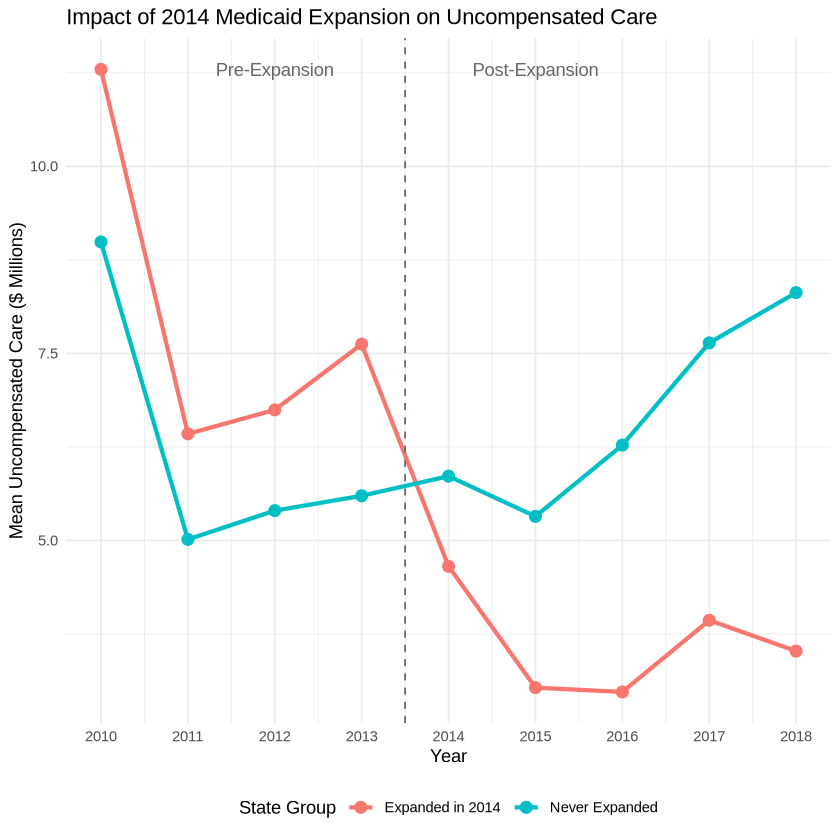

In [12]:
# Filter and Define Groups
plot_data <- final_analysis_data %>%
  filter((expand_ever == TRUE & expansion_year == 2014) | (expand_ever == FALSE)) %>%
  mutate(group = ifelse(expand_ever, "Expanded in 2014", "Never Expanded"))

# Calculate means by year and group
plot_summary <- plot_data %>%
  group_by(year, group) %>%
  summarize(mean_uncomp = mean(uncomp_millions, na.rm = TRUE), .groups = "drop")

# Create plot
ggplot(plot_summary, aes(x = year, y = mean_uncomp, color = group, group = group)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  geom_vline(xintercept = 2013.5, linetype = "dashed", color = "grey40") +
  annotate("text", x = 2012, y = max(plot_summary$mean_uncomp), label = "Pre-Expansion", color = "grey40") +
  annotate("text", x = 2015, y = max(plot_summary$mean_uncomp), label = "Post-Expansion", color = "grey40") +
  scale_x_continuous(breaks = 2010:2018) +
  theme_minimal() +
  labs(
    title = "Impact of 2014 Medicaid Expansion on Uncompensated Care",
    x = "Year",
    y = "Mean Uncompensated Care ($ Millions)",
    color = "State Group"
  ) +
  theme(legend.position = "bottom")

This graph strongly suggests a potential treatment effect. Prior to 2014 both states that did and did not expand follow paralell trends. After 2014 these two lines clearly diverge, suggesting a treatment effect.

# Question 3
Using 2012 and 2015 as your pre and post periods, present a 2x2 DD table of mean uncompensated care for expansion versus non-expansion states (again focusing only on 2014 expanders and never-expanders).

In [16]:
# Filter and set up  DD groups
dd_data <- final_analysis_data %>%
  filter(year %in% c(2012, 2015)) %>%
  filter((expand_ever == TRUE & expansion_year == 2014) | (expand_ever == FALSE)) %>%
  mutate(
    group = ifelse(expand_ever, "2014 Expanders (Treatment)", "Never Expanded (Control)"),
    period = ifelse(year == 2012, "Pre (2012)", "Post (2015)")
  )

# Calculate means
dd_table <- dd_data %>%
  group_by(group, period) %>%
  summarize(mean_uncomp = mean(uncomp_millions, na.rm = TRUE), .groups = "drop") %>%
  # Pivot into a 2x2 format
  pivot_wider(names_from = period, values_from = mean_uncomp)

# Adding differences
dd_table_final <- dd_table %>%
  mutate(Difference = `Post (2015)` - `Pre (2012)`)

# Display the table
dd_table_final


group,Post (2015),Pre (2012),Difference
<chr>,<dbl>,<dbl>,<dbl>
2014 Expanders (Treatment),3.032879,6.745352,-3.71247272
Never Expanded (Control),5.321820,5.398701,-0.07688098


# Question 4
Briefly discuss what policies or events might explain the trends you observe. Why might we expect Medicaid expansion to affect uncompensated care?

The Affordable Care Act is likely the biggest driver of this, as it was launched in 2010, but the coverage provisions didn't start until 2014. 
The Supreme Court ruling in 2012 is also another contributor, which ruled that not every state had to expand Medicaid and that's why we see some states not expanding.

# Question 5
Estimate the effect of Medicaid expansion on hospital uncompensated care using a standard DD regression estimator, focusing only on states that expanded in 2014 versus those that never expanded.

In [21]:
# Prepare data
reg_data <- final_analysis_data %>%
  filter((expand_ever == TRUE & expansion_year == 2014) | (expand_ever == FALSE)) %>%
  mutate(
    post = ifelse(year >= 2014, 1, 0),
    treat = ifelse(expand_ever == TRUE, 1, 0)
  )

# Estimate Standard DD Regression
dd_reg <- lm(uncomp_millions ~ treat + post + treat:post, data = reg_data)

summary(dd_reg)



Call:
lm(formula = uncomp_millions ~ treat + post + treat:post, data = reg_data)

Residuals:
   Min     1Q Median     3Q    Max 
 -13.9   -5.9   -3.5   -1.1 4152.9 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.0392     0.5956  10.139  < 2e-16 ***
treat         1.6368     0.7629   2.146   0.0319 *  
post          0.6481     0.7857   0.825   0.4095    
treat:post   -4.6970     1.0042  -4.677 2.92e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 40.32 on 27846 degrees of freedom
  (12422 observations deleted due to missingness)
Multiple R-squared:  0.0017,	Adjusted R-squared:  0.001593 
F-statistic: 15.81 on 3 and 27846 DF,  p-value: 2.884e-10


# Question 6
Include hospital and year fixed effects in your estimates using the fixest package. Cluster your standard errors at the state level. How do your results compare to those in question 5?

In [23]:
# Filter the data
reg_data_fe <- final_analysis_data %>%
  filter((expand_ever == TRUE & expansion_year == 2014) | (expand_ever == FALSE))

# Estimate the Model
fe_model <- feols(uncomp_millions ~ expand | provider_number + year, 
                  cluster = ~state, 
                  data = reg_data_fe)

summary(fe_model)

NOTE: 12,422 observations removed because of NA values (LHS: 12,422).



OLS estimation, Dep. Var.: uncomp_millions
Observations: 27,850 
Fixed-effects: provider_number: 3,693,  year: 9
Standard-errors: Clustered (state) 
           Estimate Std. Error t value  Pr(>|t|)    
expandTRUE -5.09824    1.74747 -2.9175 0.0060446 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 30.3     Adj. R2: 0.351168
             Within R2: 0.001555

Medicaid expansion seems to cause a significant drop in uncompensated care

# Question 7
Repeat the analysis in question 6 but include all states (even those that expanded after 2014). Are your results different? If so, why?

In [24]:
# Estimate the model using all states
fe_model_all <- feols(uncomp_millions ~ expand | provider_number + year, 
                      cluster = ~state, 
                      data = final_analysis_data)

summary(fe_model_all)

NOTE: 17,715 observations removed because of NA values (LHS: 17,715).



OLS estimation, Dep. Var.: uncomp_millions
Observations: 37,022 
Fixed-effects: provider_number: 4,930,  year: 9
Standard-errors: Clustered (state) 
           Estimate Std. Error  t value  Pr(>|t|)    
expandTRUE -4.18838    1.37134 -3.05421 0.0035537 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 26.6     Adj. R2: 0.356639
             Within R2: 0.001563

These results are different in what the show. Results from 6 show how the change occurred over time, while results from 7 show how much of a change has occurred. 

# Question 8
Provide an “event study” graph showing the effects of Medicaid expansion in each year. Use the specification that includes hospital and year fixed effects, limited to states that expanded in 2014 or never expanded (with 2013 as the reference year).



NOTE: 12,422 observations removed because of NA values (LHS: 12,422).



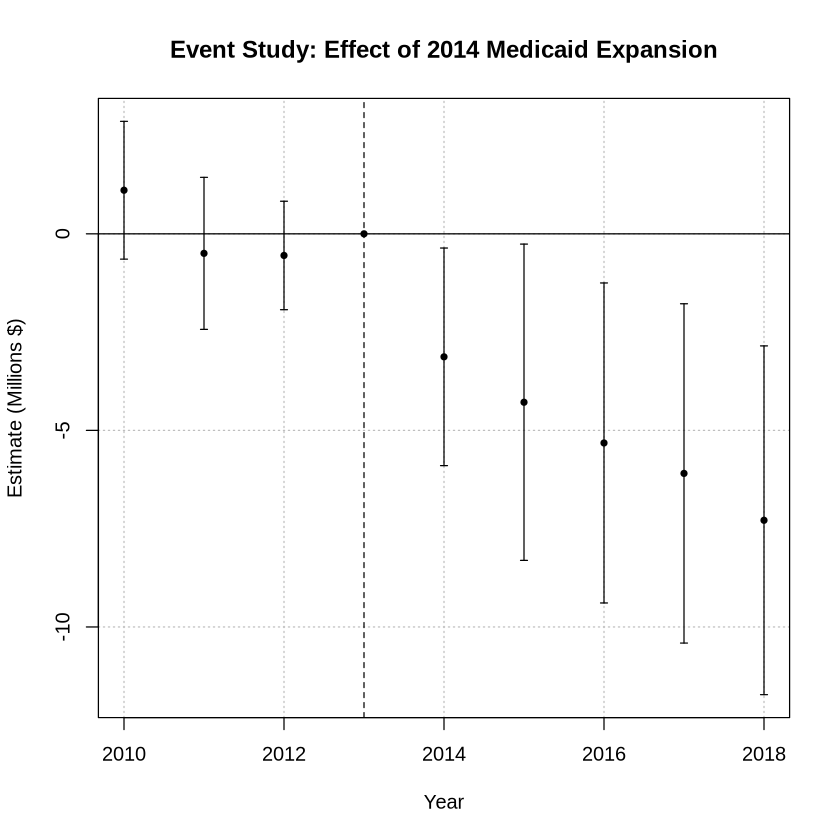

In [27]:
# Filter  data
event_data <- final_analysis_data %>%
  filter((expand_ever == TRUE & expansion_year == 2014) | (expand_ever == FALSE))

# Run the event study regression
event_study_model <- feols(uncomp_millions ~ i(year, expand_ever, ref = 2013) | 
                             provider_number + year, 
                           cluster = ~state, 
                           data = event_data)

# Plot 
iplot(event_study_model, 
      main = "Event Study: Effect of 2014 Medicaid Expansion",
      xlab = "Year",
      ylab = "Estimate (Millions $)",
      sep = 0.5)

# Question 9
Repeat part 8 but include all states that expanded after 2014. You will need to construct an “event time” variable and bin end points as discussed in class.

NOTE: 17,715 observations removed because of NA values (LHS: 17,715).



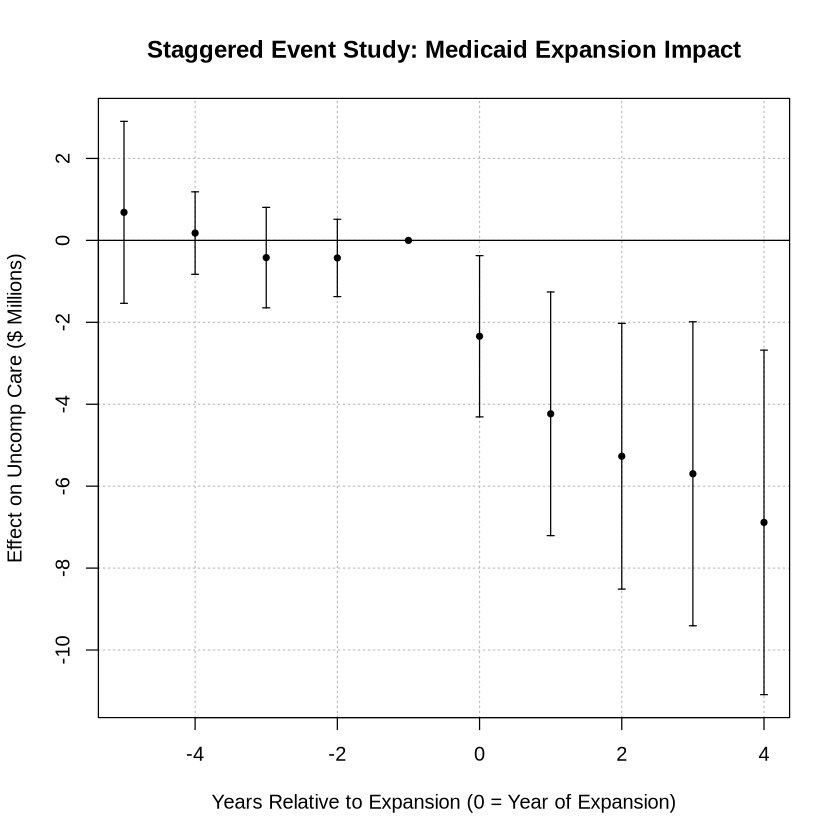

In [28]:
# Event Time variable
event_study_data <- final_analysis_data %>%
  mutate(
    event_time = year - expansion_year,
    event_time = ifelse(is.na(event_time), -1, event_time),
    event_time_binned = case_when(
      event_time <= -5 ~ -5,
      event_time >= 5 ~ 5,
      TRUE ~ event_time
    )
  )

# Run fixed effects model
staggered_model <- feols(uncomp_millions ~ i(event_time_binned, ref = -1) | 
                           provider_number + year, 
                         cluster = ~state, 
                         data = event_study_data)

# Plot
iplot(staggered_model, 
      main = "Staggered Event Study: Medicaid Expansion Impact",
      xlab = "Years Relative to Expansion (0 = Year of Expansion)",
      ylab = "Effect on Uncomp Care ($ Millions)",
      grid = TRUE)

# Question 10
Summarize your findings from questions 5-9. What is the effect of Medicaid expansion on hospital uncompensated care? Do the event study graphs suggest any concerns about the parallel trends assumption? Briefly discuss one limitation of the standard TWFE estimator in the context of staggered Medicaid expansion.

these results show that Medicaid expansion reduced hospitals uncompensated care costs. These results don't suggest significant concerns regarding the parallel trends assumption because in the estimates for the years before the expansion are close to the zero line. One limitation would be negative weighting, in this comparison states that expanded early could become controls for states taht expanded later. 